# Tarea N°2

**Variable dictionary**

- folio_n20:	identificacion individuo
- year:	anio 20xx
- time:	ronda de la encuesta (1-7)
- age:	edad
- hombre:	1 si hombre, 0 mujer
- edu:	educacion medida en anios completados
- region:	region (1-16)
- status:	1 casado 2 convive 3 divorciado 4 viudo 5 soltero
- kids:	1 if has kids, 0 ow
- children:	# of children under 18 years old, 18 included
- situation:	1 otro, 2 cesante, 3 trabajando, 4 inactivo
- lmp:	1 part-time worker, 2 full-time worker, 0 not working
- exp:	years of labor experience
- size:	tamanio de la firma
- occupation:	codigo ocupacion
- wage:	salario mensual en pesos del anio encuesta
- hours:	horas semanales trabajadas
- informal:	1 if no work contract, 0 ow
- selfemp:	1 if self employed, 0 ow
- publicemp:	1 if worker in public sector, 0 ow
- sistema:	1 if in AFP system, 0 ow
- cotizando:	1 if contributor, 0 ow
- assets:	accumulated wealth in pension system, pesos of each year
- exp_sist:	years of experience in pension system
- expectancy:	expectativa de vida autorreportada
- illness:	1 si tiene al menos una enferdad, 0 si no
- cronica:	Si tiene enfermedad cronica 1, 0 eoc
- nocronica:	Si tiene enfermedad no cronica 1, 0 eoc
- mental:	Si tiene enfermedad mental 1, 0 eoc

In [556]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.iolib.summary2 import summary_col
import sklearn
from sklearn.preprocessing import StandardScaler
import scipy 
from scipy.stats import nbinom
import seaborn as sns
import warnings
from statsmodels.genmod.families import NegativeBinomial
warnings.filterwarnings("ignore")
from linearmodels.panel import PooledOLS
from statsmodels.stats.outliers_influence import variance_inflation_factor

%matplotlib inline


1. Cargar la base de datos en el ambiente. Identifique los tipos de datos que se encuentran en la base, realice estadisticas descriptivas sobre las variables importantes (Hint: Revisar la distribuciones, datos faltantes, outliers, etc.) y limpie las variables cuando sea necesario.

In [557]:
url="https://raw.githubusercontent.com/juancaros/LAB-MAA/refs/heads/main/data/panel_eps.csv"
df=pd.read_csv(url)
df

,folio_n20,year,time,edad,hombre,edu,region,status,kids,children,...,fondob,fondoc,fondod,fondoe,exp_sist,expectancy,illness,cronica,nocronica,mental
0,124560204870,4,2,49,0.0,7.0,5.0,3.0,1,1.0,...,NaN,NaN,NaN,NaN,0,58.0,1.0,0.0,1.0,0.0
1,124560204870,6,3,51,0.0,4.0,5.0,3.0,1,1.0,...,NaN,NaN,NaN,NaN,0,55.0,0.0,0.0,0.0,0.0
2,124560204870,9,4,54,0.0,5.0,5.0,3.0,1,1.0,...,NaN,NaN,NaN,NaN,0,70.0,1.0,0.0,0.0,1.0
3,124560204870,12,5,57,0.0,4.0,NaN,5.0,0,0.0,...,NaN,NaN,NaN,NaN,0,70.0,1.0,0.0,0.0,0.0
4,124560205935,2,1,1982,0.0,15.0,13.0,3.0,1,4.0,...,NaN,NaN,NaN,NaN,19,75.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96841,128133653188,12,5,1992,0.0,16.0,NaN,3.0,0,0.0,...,NaN,NaN,NaN,NaN,7,80.0,0.0,0.0,0.0,0.0
96842,128133692735,12,5,1992,0.0,12.0,NaN,2.0,0,0.0,...,NaN,NaN,NaN,NaN,7,80.0,1.0,0.0,0.0,0.0
96843,128133702320,12,5,1992,0.0,15.0,NaN,5.0,0,0.0,...,NaN,NaN,NaN,NaN,7,75.0,0.0,0.0,0.0,0.0
96844,128133728022,12,5,1992,0.0,8.0,NaN,2.0,0,0.0,...,NaN,NaN,NaN,NaN,6,70.0,1.0,0.0,0.0,0.0


In [558]:
# Variables dummies para ocupación (con drop_first=False para mantener consistencia con el notebook original)
occupation_dummies = pd.get_dummies(df['occupation'], prefix='occupation')
df = pd.concat([df, occupation_dummies], axis=1)

In [559]:

# Primero eliminamos columnas completamente vacías
df = df.drop(columns=["fondoa", "fondob", "fondoc", "fondod", "fondoe"], errors="ignore")

# Arreglamos 'assets' y la convertimos en numérica
df["assets"] = df["assets"].replace(",", "", regex=True)
df["assets"] = pd.to_numeric(df["assets"], errors="coerce")

# Dado que en variable edad hay algunos datos expresados en años, lo arreglamos restando ese valor a la variable year.
df["edad"] = pd.to_numeric(df["edad"], errors="coerce")
cond_nacimiento = df["edad"] > 1000
df.loc[cond_nacimiento, "edad"] = (2000 + df.loc[cond_nacimiento, "year"]) - df.loc[cond_nacimiento, "edad"]

# Rellenar region usando folio_n20
df["region"] = df.groupby("folio_n20")["region"].transform(lambda x: x.ffill().bfill())

# Dropeamos occupation porque tiene % de NaN altos y no se tiene información del significado de cada código
df=df.drop(columns=["occupation"],errors="ignore")

# Creamos variables indicadoras para las variables que tiene % de NaN altos
vars_missing = [
    'informal', 'wage', 'hours', 'selfemp', 'publicemp', 
    'expectancy', 'sistema', 'children', 'illness',
    'cronica', 'nocronica', 'mental', 'assets', 'exp'
]

for var in vars_missing:
    df[f'missing_{var}'] = df[var].isna().astype(int)


# Condicionamos las variables que tengan relacion con el la situación de empleo de la persona
employment_vars = ['informal', 'wage', 'hours', 'selfemp', 'publicemp']

for var in employment_vars:
    employed_mask = (df['situation'] == 3) & df[var].isna()
    not_employed_mask = (df['situation'].isin([1,2, 4])) & df[var].isna()
    
    if var == 'informal':
        # Para empleados: usar moda de empleados (o 0 si no hay)
        mode_result = df[df['situation'] == 3][var].mode()
        df.loc[employed_mask, var] = mode_result[0] if not mode_result.empty else 0
        # Para no empleados: 0
        df.loc[not_employed_mask, var] = 0
        
    elif var == 'wage':
        # Estrategia mejorada para salarios
        # Se imputa medaina por educacipon y situación 
        df.loc[employed_mask, var] = df[df['situation'] == 3].groupby(  # Corregido: situation == 3
            ['edu', 'informal'])[var].transform(
            lambda x: x.median() if not x.isnull().all() else np.nan)
        
        # Si hay NAns, se imputa mediana por educación
        still_na = employed_mask & df[var].isna()
        df.loc[still_na, var] = df[df['situation'] == 3].groupby(  # Corregido: situation == 3
            ['edu'])[var].transform(
            lambda x: x.median() if not x.isnull().all() else np.nan)
        
        #  Si hay NAs, usar mediana general
        still_na = employed_mask & df[var].isna()
        median_wage = df[df['situation'] == 3][var].median()  # Corregido: situation == 3
        df.loc[still_na, var] = median_wage if not pd.isna(median_wage) else 0
        
        # Para no empleados
        df.loc[not_employed_mask, var] = 0
        
    else:  # selfemp, publicemp
        # Para empleados: moda de empleados (o 0)
        mode_result = df[df['situation'] == 3][var].mode()
        df.loc[employed_mask, var] = mode_result[0] if not mode_result.empty else 0
        # Para no empleados: 0
        df.loc[not_employed_mask, var] = 0

# Imputación para variables no laborales
other_vars = [
    'expectancy', 'sistema', 'children', 'illness',
    'cronica', 'nocronica', 'mental', 'assets', 'exp'
]

for var in other_vars:
    if df[var].dtype == 'object':
        mode_result = df[var].mode()
        df[var] = df[var].fillna(mode_result[0] if not mode_result.empty else 'unknown')
    else:
        median_value = df[var].median()
        df[var] = df[var].fillna(median_value if not pd.isna(median_value) else 0)

# Verificamos % de NaN 
print((df.isna().mean() * 100).sort_values(ascending=False))


# Creamos variables dummies
df = pd.get_dummies(df, columns=["status", "situation", "lmp", "region"], prefix=["status", "situation", "lmp", "region",], drop_first=True)

# Convertimos las columnas tipo bool a int (0/1)
df = df.astype({col: 'int' for col in df.select_dtypes(include='bool').columns})

# Valores irreales de expectancy
df = df[(df['expectancy'] >= 40) & (df['expectancy'] <= 120)]


size                  70.010119
region                 6.805650
cotizando              4.964583
edu                    4.053859
status                 0.113582
hombre                 0.051628
year                   0.000000
time                   0.000000
edad                   0.000000
kids                   0.000000
situation              0.000000
folio_n20              0.000000
lmp                    0.000000
exp                    0.000000
wage                   0.000000
hours                  0.000000
informal               0.000000
selfemp                0.000000
publicemp              0.000000
children               0.000000
sistema                0.000000
assets                 0.000000
exp_sist               0.000000
expectancy             0.000000
illness                0.000000
cronica                0.000000
nocronica              0.000000
mental                 0.000000
occupation_1.0         0.000000
occupation_2.0         0.000000
occupation_3.0         0.000000
occupati

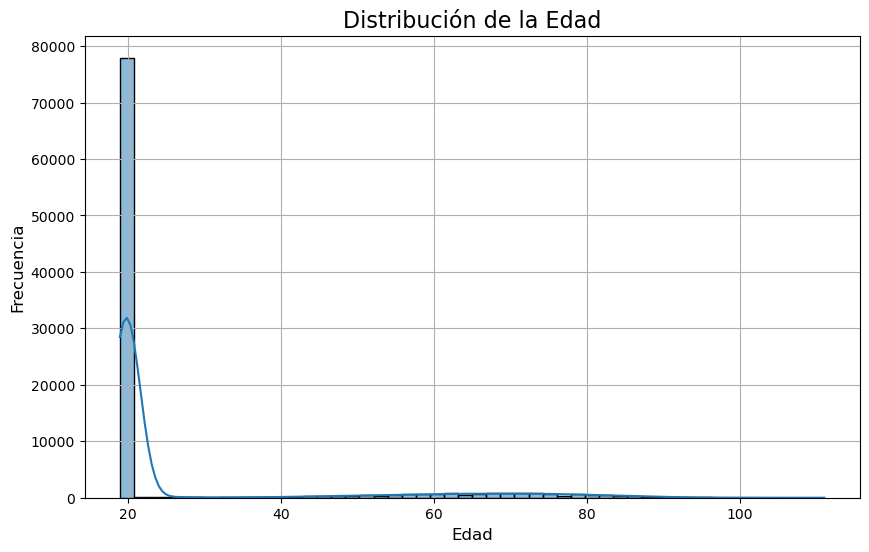

In [560]:
plt.figure(figsize=(10, 6))
sns.histplot(df['edad'].dropna(), bins=50, kde=True)

plt.title("Distribución de la Edad", fontsize=16)
plt.xlabel("Edad", fontsize=12)
plt.ylabel("Frecuencia", fontsize=12)
plt.grid(True)
plt.show()

In [561]:
#Eliminamos la edad ya que tiene muchos valores de personas 20 años al trabajar la variable.
df = df.drop(columns=["edad"], errors="ignore")

In [562]:
df

,folio_n20,year,time,hombre,edu,kids,children,exp,size,wage,...,region_6.0,region_7.0,region_8.0,region_9.0,region_10.0,region_11.0,region_12.0,region_13.0,region_14.0,region_15.0
0,124560204870,4,2,0.0,7.0,1,1.0,12.0,NaN,0.0,...,0,0,0,0,0,0,0,0,0,0
1,124560204870,6,3,0.0,4.0,1,1.0,12.0,NaN,0.0,...,0,0,0,0,0,0,0,0,0,0
2,124560204870,9,4,0.0,5.0,1,1.0,12.0,NaN,0.0,...,0,0,0,0,0,0,0,0,0,0
3,124560204870,12,5,0.0,4.0,0,0.0,12.0,NaN,50000.0,...,0,0,0,0,0,0,0,0,0,0
4,124560205935,2,1,0.0,15.0,1,4.0,6.0,NaN,0.0,...,0,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96841,128133653188,12,5,0.0,16.0,0,0.0,12.0,NaN,0.0,...,0,0,0,0,0,0,0,0,0,0
96842,128133692735,12,5,0.0,12.0,0,0.0,12.0,NaN,150000.0,...,0,0,0,0,0,0,0,0,0,0
96843,128133702320,12,5,0.0,15.0,0,0.0,12.0,NaN,0.0,...,0,0,0,0,0,0,0,0,0,0
96844,128133728022,12,5,0.0,8.0,0,0.0,12.0,NaN,183000.0,...,0,0,0,0,0,0,0,0,0,0


In [563]:
df.dtypes

folio_n20        int64
year             int64
time             int64
hombre         float64
edu            float64
                ...   
region_11.0      int64
region_12.0      int64
region_13.0      int64
region_14.0      int64
region_15.0      int64
Length: 70, dtype: object

In [564]:
print("\nResumen por tipo:")
print(df.dtypes.value_counts())


Resumen por tipo:
int64      52
float64    18
Name: count, dtype: int64


In [565]:
#Revisamos la cantidad de datos vacios por variable
df.isnull().sum().sort_values(ascending=False).head(10)


size         63565
cotizando     4793
edu           3866
hombre          48
year             0
time             0
children         0
exp              0
folio_n20        0
wage             0
dtype: int64

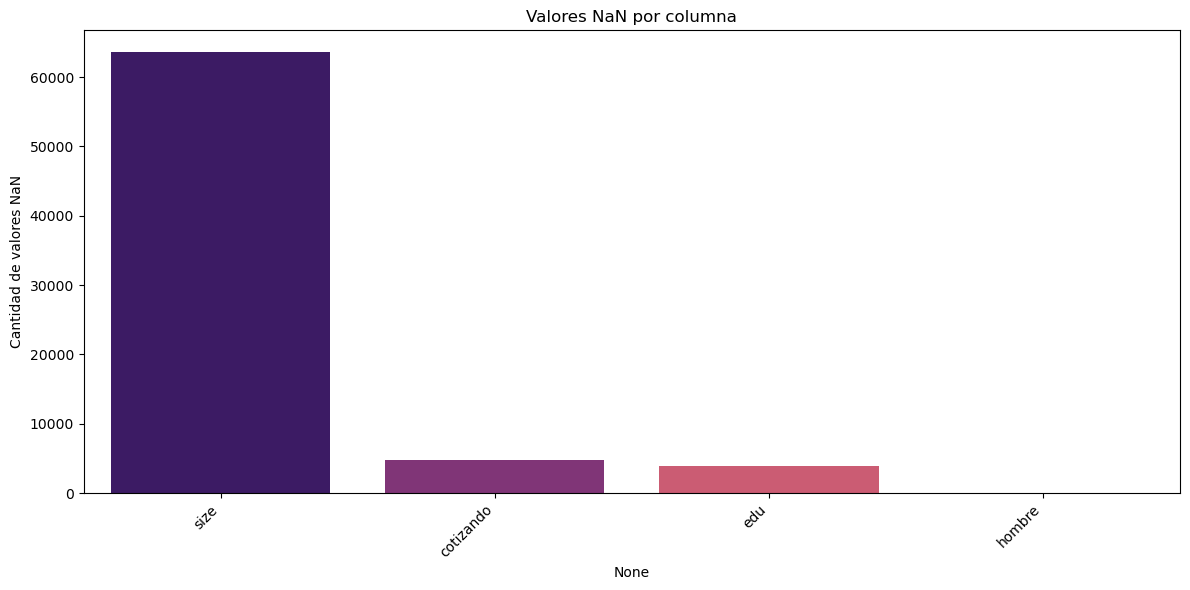

In [566]:
nan_counts = df.isna().sum()
nan_counts_with_nan = nan_counts[nan_counts > 0].sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=nan_counts_with_nan.index, y=nan_counts_with_nan.values, palette='magma')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Cantidad de valores NaN')
plt.title('Valores NaN por columna')
plt.tight_layout()
plt.show()


In [567]:
#Dado que faltan muchos variables para size y que no es relevante para nuestro análisis, la eliminamos.
df = df.drop(columns=["size"], errors="ignore")


In [568]:

df.describe().T


,count,mean,std,min,25%,50%,75%,max
folio_n20,92589.0,1.253244e+11,1.302004e+09,1.245602e+11,1.246218e+11,1.247077e+11,1.248372e+11,1.281337e+11
year,92589.0,7.946570e+00,4.663346e+00,2.000000e+00,4.000000e+00,6.000000e+00,1.200000e+01,1.500000e+01
time,92589.0,3.471395e+00,1.762499e+00,1.000000e+00,2.000000e+00,3.000000e+00,5.000000e+00,6.000000e+00
hombre,92541.0,4.956290e-01,4.999836e-01,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00
edu,88723.0,7.969771e+00,5.111973e+00,0.000000e+00,4.000000e+00,8.000000e+00,1.200000e+01,1.900000e+01
...,...,...,...,...,...,...,...,...
region_11.0,92589.0,7.193079e-03,8.450690e-02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
region_12.0,92589.0,8.845543e-03,9.363436e-02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
region_13.0,92589.0,3.491235e-01,4.766957e-01,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00
region_14.0,92589.0,6.793464e-03,8.214247e-02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00


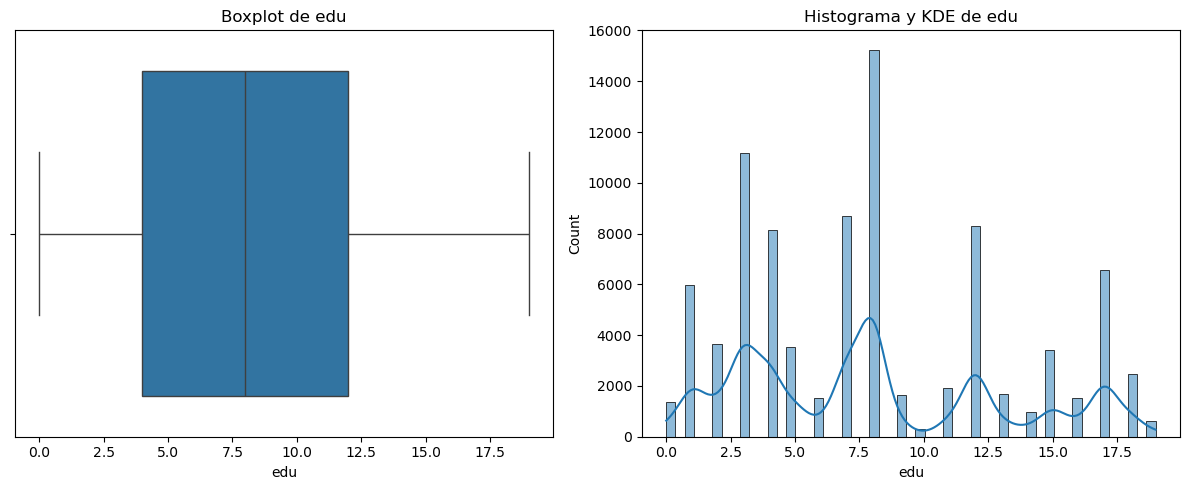

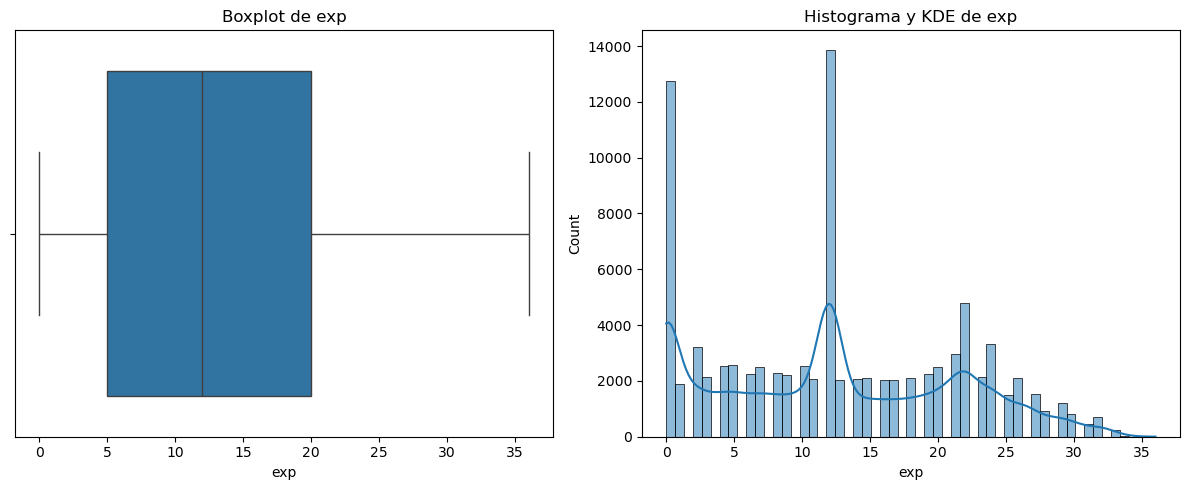

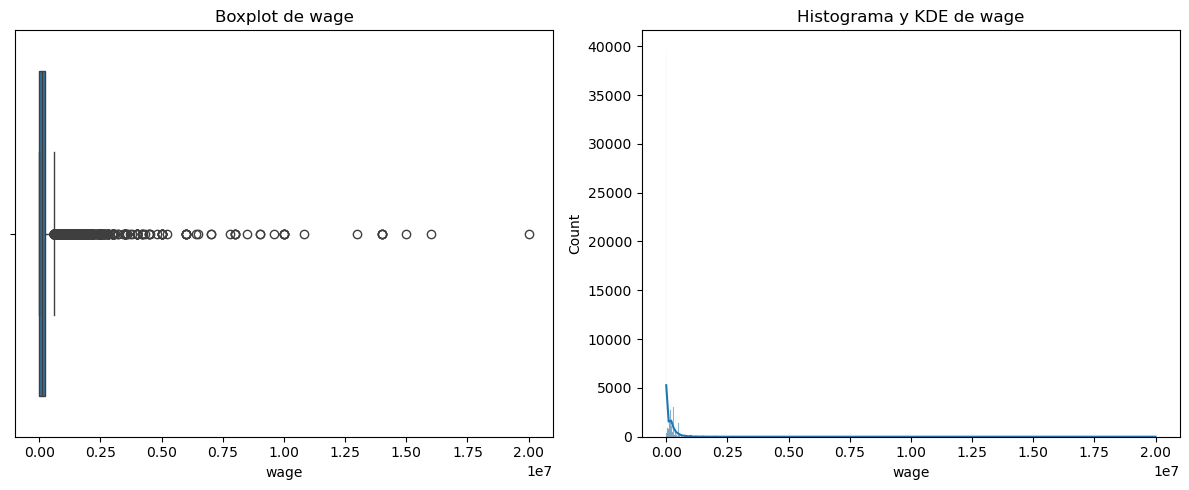

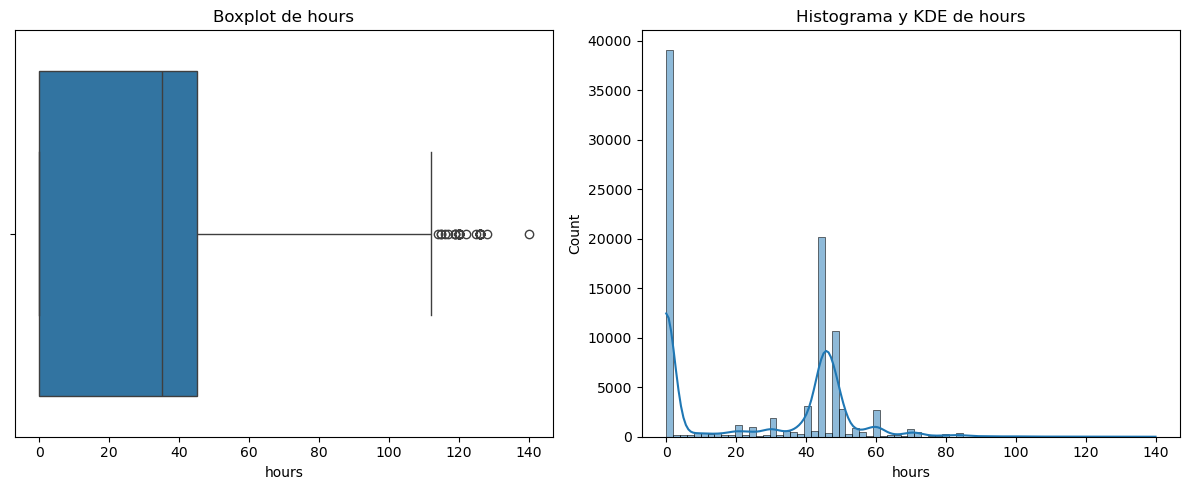

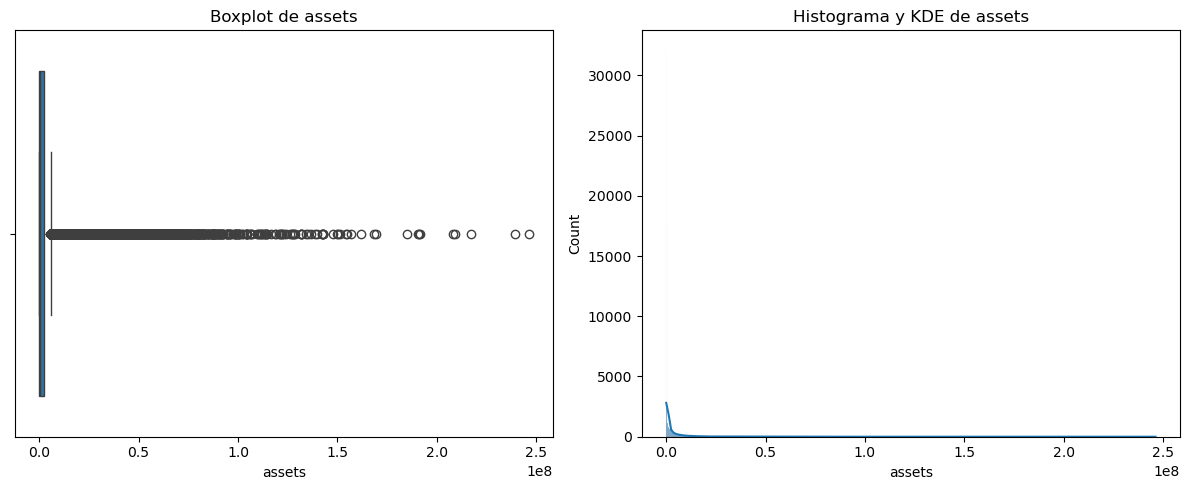

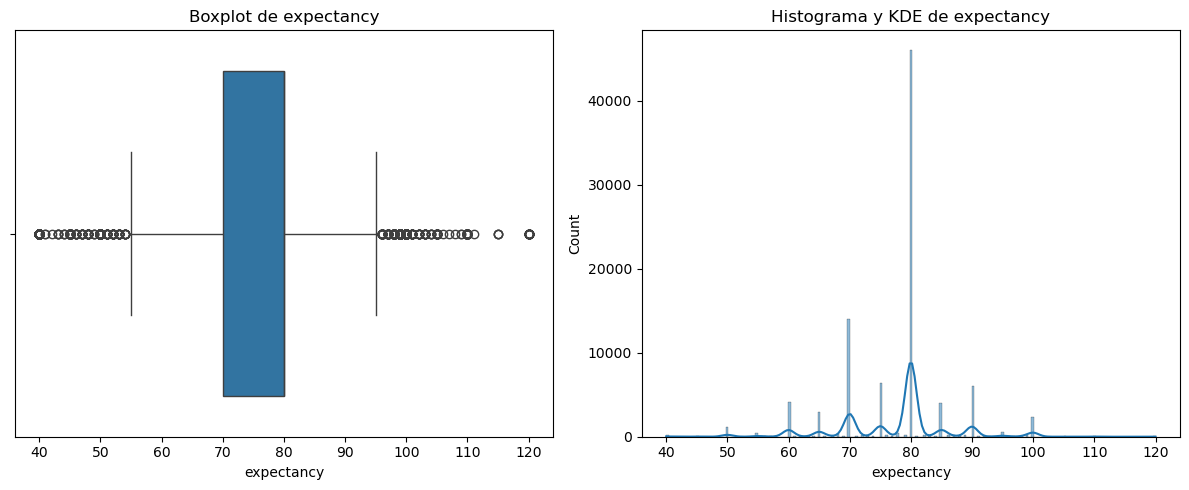

In [569]:


# Identificar variables numéricas
num_cols = df.select_dtypes(include=['float64', 'int64']).columns

# Excluir columnas irrelevantes o poco informativas para visualización
exclude_cols = [
    'folio_n20', 'time', 'region', 'status', 'kids', 'children',
    'exp_sist', 'mental', 'illness', 'nocronica', 'hombre',
    'missing_expectancy', 'missing_exp', 'missing_assets'
]

# Filtrar variables numéricas útiles con suficiente variación
cont_cols = [
    col for col in num_cols
    if col not in exclude_cols and df[col].nunique() > 10 and not col.startswith("region_") and not col.startswith("status_")
]

# Graficar boxplot + histograma con KDE
for col in cont_cols:
    plt.figure(figsize=(12, 5))

    # Boxplot
    plt.subplot(1, 2, 1)
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot de {col}')

    # Histograma con KDE
    plt.subplot(1, 2, 2)
    sns.histplot(df[col], kde=True)
    plt.title(f'Histograma y KDE de {col}')

    plt.tight_layout()
    plt.show()


In [570]:
# Vemos el porcentaje de outliers
outlier_counts = {}

# Seleccionamos columnas numéricas que NO son missing
numeric_cols = [
    col for col in df.select_dtypes(include=['int64', 'float64']).columns
    if not col.startswith("missing_")
]

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    outlier_counts[col] = len(outliers)

# Ordenamos de mayor a menor
outlier_counts = dict(sorted(outlier_counts.items(), key=lambda item: item[1], reverse=True))

# Imprimimos en porcentaje
for k, v in outlier_counts.items():
    print(f"{k}: {(v / len(df)) * 100:.2f}% outliers")


folio_n20: 18.70% outliers
cronica: 16.93% outliers
assets: 14.11% outliers
region_8.0: 11.83% outliers
selfemp: 10.98% outliers
status_2.0: 10.82% outliers
sistema: 10.37% outliers
occupation_9.0: 10.35% outliers
region_5.0: 9.83% outliers
publicemp: 8.67% outliers
occupation_7.0: 8.48% outliers
status_3.0: 8.47% outliers
situation_2: 8.33% outliers
occupation_5.0: 7.96% outliers
region_7.0: 6.57% outliers
informal: 6.41% outliers
status_4.0: 6.23% outliers
region_10.0: 6.16% outliers
mental: 6.04% outliers
nocronica: 5.88% outliers
children: 5.58% outliers
region_6.0: 5.55% outliers
occupation_4.0: 5.53% outliers
occupation_8.0: 5.44% outliers
region_9.0: 5.01% outliers
expectancy: 4.82% outliers
occupation_3.0: 4.57% outliers
region_4.0: 4.35% outliers
wage: 4.27% outliers
occupation_2.0: 4.09% outliers
lmp_1: 3.79% outliers
occupation_6.0: 2.79% outliers
region_2.0: 2.51% outliers
occupation_1.0: 2.08% outliers
region_3.0: 1.60% outliers
region_12.0: 0.88% outliers
region_11.0: 0.7

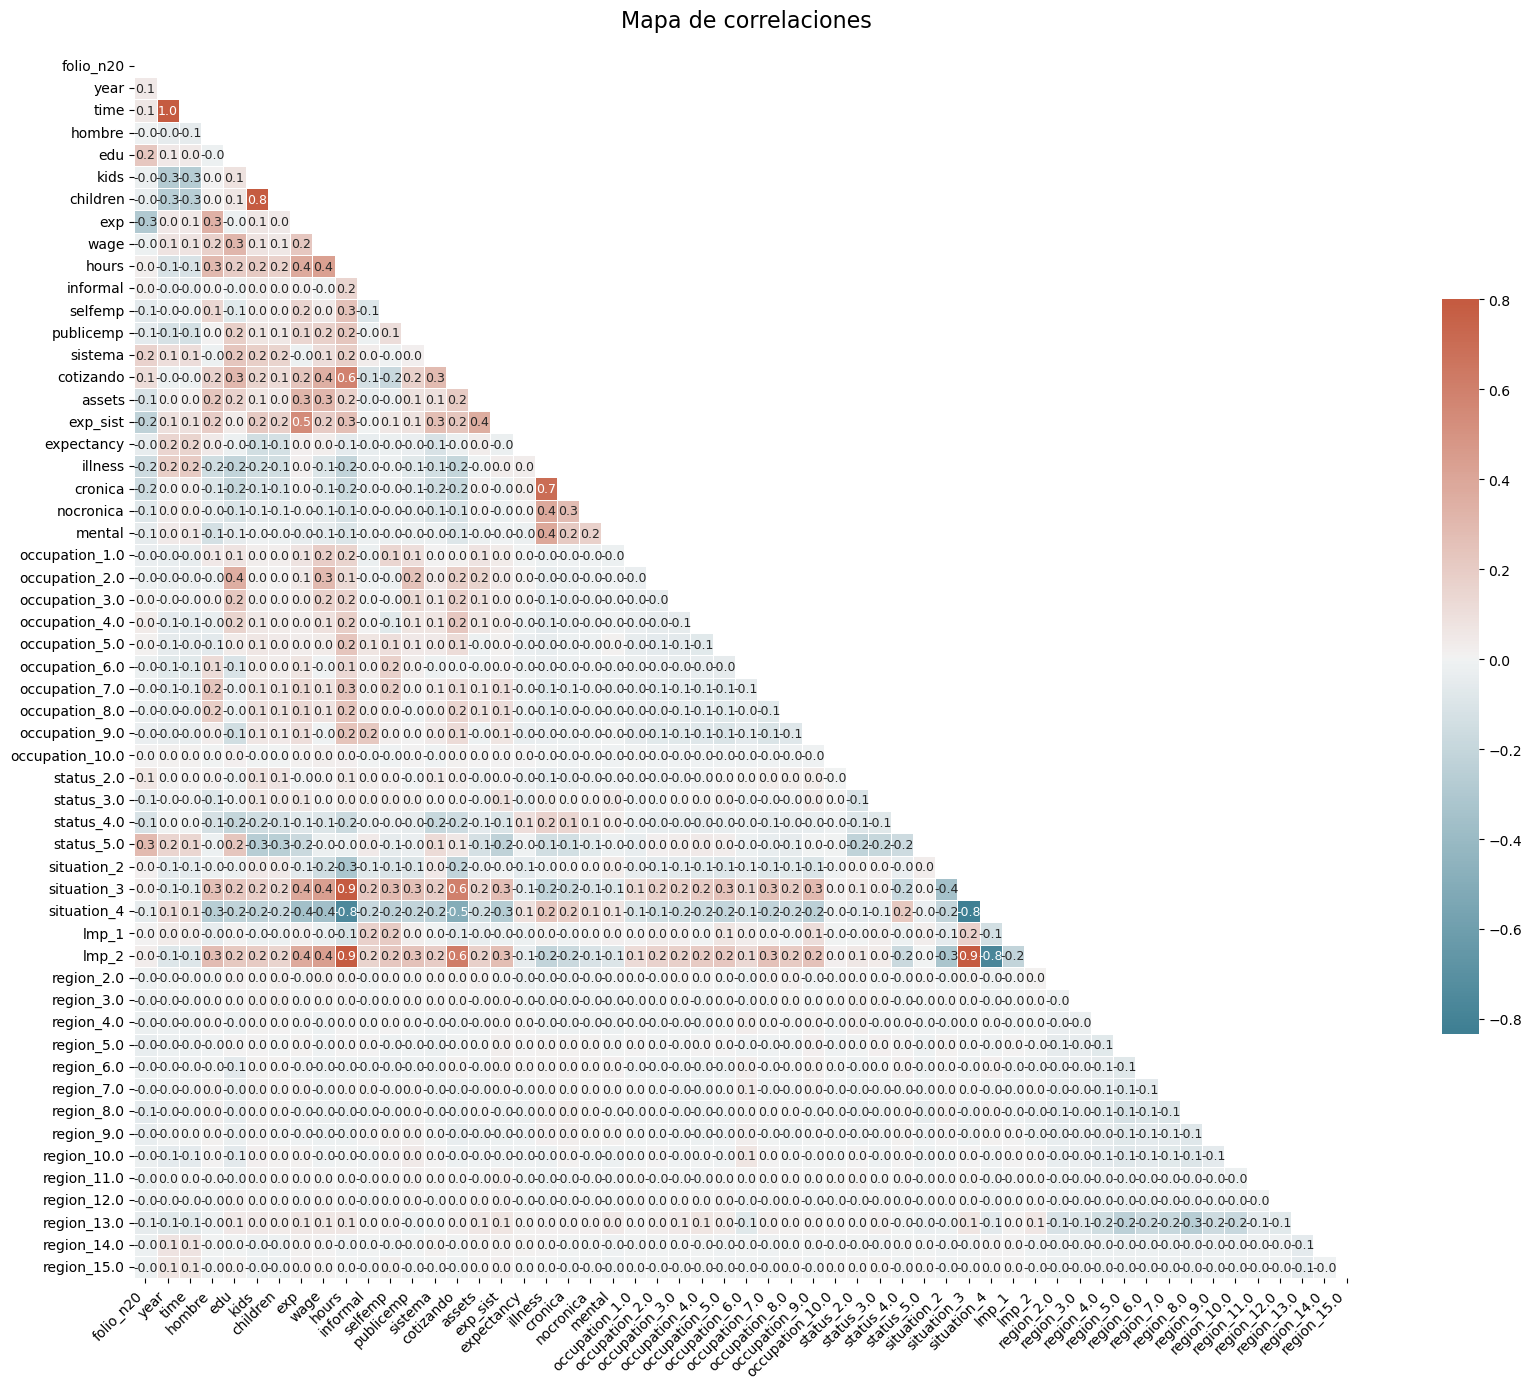

In [571]:

#Excluimos las missing
numeric_cols = [col for col in df.select_dtypes(include='number').columns if not col.startswith("missing_")]

# Matriz de correlación
corr = df[numeric_cols].corr()


mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(18, 14))  # Aumentamos tamaño
cmap = sns.diverging_palette(220, 20, as_cmap=True)

# Heatmap
sns.heatmap(
    corr,
    mask=mask,
    cmap=cmap,
    vmax=0.8,
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.6},
    annot=True,
    fmt=".1f",
    annot_kws={"size": 9}
)

# Rotar etiquetas
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.title("Mapa de correlaciones", fontsize=16, pad=20)
plt.tight_layout()
plt.show()


In [572]:
#Eliminamos periodos 1 y 6

df = df[df['time'] != 1]
df = df[df['time'] != 6]

In [573]:
df.describe()

,folio_n20,year,time,hombre,edu,kids,children,exp,wage,hours,...,region_6.0,region_7.0,region_8.0,region_9.0,region_10.0,region_11.0,region_12.0,region_13.0,region_14.0,region_15.0
count,5.939100e+04,59391.000000,59391.000000,59353.000000,58505.000000,59391.000000,59391.000000,59391.000000,5.939100e+04,59391.000000,...,59391.000000,59391.000000,59391.000000,59391.000000,59391.000000,59391.000000,59391.000000,59391.000000,59391.000000,59391.000000
mean,1.254674e+11,7.570019,3.429560,0.487743,7.796821,0.363843,0.599434,12.683976,1.570034e+05,25.598794,...,0.054621,0.063865,0.116886,0.049789,0.059622,0.006449,0.007998,0.330488,0.005843,0.005338
std,1.403436e+09,3.146185,1.159956,0.499854,5.075466,0.481108,0.947756,9.108814,3.254184e+05,24.353800,...,0.227241,0.244514,0.321288,0.217510,0.236787,0.080046,0.089073,0.470393,0.076214,0.072864
min,1.245602e+11,4.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.246198e+11,4.000000,2.000000,0.000000,3.000000,0.000000,0.000000,4.000000,0.000000e+00,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.247935e+11,6.000000,3.000000,0.000000,7.000000,0.000000,0.000000,12.000000,1.000000e+05,30.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.248537e+11,12.000000,5.000000,1.000000,12.000000,1.000000,1.000000,21.000000,2.000000e+05,45.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
max,1.281337e+11,12.000000,5.000000,1.000000,19.000000,1.000000,8.000000,33.000000,2.000000e+07,126.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [574]:
#Transformamos a logaritmo

df['wage'] = np.log1p(df['wage'])
df['assets'] = np.log1p(df['assets'])



# Pooled OLS
2. Ejecute un modelo Pooled OLS para estimar la relacion entre los anios de educacion y la expectativa de vida. Seleccione las variables independientes a incluir en el modelo final e interprete su significado.

In [575]:
df = df.set_index(["folio_n20","time"])

In [576]:
df = df.dropna()

In [577]:
import linearmodels.panel as lmp


# Eliminamos variables que no necesitamos para nuestro analisis ya que están directamente relacionadas con otras.
X = df.drop(columns=[
    'expectancy', 'illness', 'children', 
    'nocronica', 'exp_sist'
])

# Se eliminan columnas con baja variación
X = X.loc[:, X.nunique() > 1] 


# Calcular VIF y eliminar variables problemáticas
vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# Eliminar variables con VIF infinito o muy alto
high_vif = vif_data[vif_data["VIF"] > 1000]['Variable']
X = X.drop(columns=high_vif)

# Eliminar filas con NaN
df_clean = pd.concat([y, X], axis=1)
y_clean = df_clean['expectancy']
X_clean = sm.add_constant(df_clean.drop(columns=['expectancy']))


# Diagnóstico post-estimación
print("\nResumen de multicolinealidad:")
print(vif_data.sort_values("VIF", ascending=False))


Resumen de multicolinealidad:
              Variable        VIF
41         situation_3        inf
29   missing_publicemp        inf
28     missing_selfemp        inf
43               lmp_1        inf
44               lmp_2        inf
42         situation_4  86.076592
5                 wage  66.630662
40         situation_2  33.478850
27       missing_hours  20.214818
26        missing_wage  12.695784
6                hours  10.305009
25    missing_informal   8.434994
56         region_13.0   6.251521
34      missing_assets   4.621430
8              selfemp   3.938410
51          region_8.0   3.503090
0                 year   3.287589
48          region_5.0   3.096248
11           cotizando   2.938728
23      occupation_9.0   2.747175
50          region_7.0   2.507709
53         region_10.0   2.464340
21      occupation_7.0   2.372733
19      occupation_5.0   2.351576
49          region_6.0   2.299587
12              assets   2.176963
52          region_9.0   2.155470
47          regio

In [578]:
# Creamos nuestra variable independiente
y=df['expectancy']

df_clean = pd.concat([y, X], axis=1)
y_clean = df_clean['expectancy']
X_clean = sm.add_constant(df_clean.drop(columns=['expectancy']))

# Modelo PooledOLS con verificación de rango desactivada
model = lmp.PanelOLS(y_clean, X_clean);
results = model.fit()

# Resultados
print(results.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:             expectancy   R-squared:                        0.0601
Estimator:                   PanelOLS   R-squared (Between):              0.0783
No. Observations:               54125   R-squared (Within):               0.0103
Date:                Tue, May 20 2025   R-squared (Overall):              0.0601
Time:                        20:53:54   Log-likelihood                -1.975e+05
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      64.063
Entities:                       22898   P-value                           0.0000
Avg Obs:                       2.3637   Distribution:                F(54,54070)
Min Obs:                       1.0000                                           
Max Obs:                       4.0000   F-statistic (robust):             64.063
                            

R: Primero podemos notar que tenemos un R cuadrado Overall con un valor de 0.0628, es decir, que las variables independientes solo pueden explicar el 6,28% de la variación en la expectativa de vida. Podemos suponer que la expectativa de  vida esta relacionada a variables que no poseemos, en función de esto sugeriría buscar más datos relacionados a la salud y agregarlos al data frame.

Luego, tenemos que la constante es de 79,8 años correspondiente a la expectativa de vida base, manteniendo el resto de variables como 0.
En cuanto a la relación de los años de eduación con la expectativa de vida, el modelo Pooled OLS nos entrega un coeficiente negativo de 0,028, lo que significa que por cada año de educación, la expectativa de vida baja en 0,03 años aproximadamente. Además, esta variable cuenta con un p muy alto, por lo que no es significativa. 

Otras variables relevantes son year con un coeficiente de 0,1437, que significa que por cada año, nuestra expectativa de vida aumenta en 0,14 años, y también vemos que los hombres viven 1,4 años más que las mujeres aproximadamente.

Finalmente, a modo general notamos que hay varias variables con un p alto, por lo que no son significativas y otras con un VIF muy alto lo que implica una gran colinealidad.


# Efectos Fijos
3. Ejecute un modelo efectos fijos para estimar la misma relacion anterior. Seleccione las variables independientes a incluir en el modelo final e interprete su significado.

In [579]:
from linearmodels.panel import PanelOLS
import statsmodels.api as sm

#Variable dependiente
y = df["expectancy"]


#Dado que muchas variables en el modelo anterior tienen un p o VIF muy altos decidimos eliminarlas.
#Después de ir probando correr el modelo con diferentes variables independintes, llegamos a que este es el mejor conjunto.
X = df[["edu","kids","exp","cronica","sistema", "wage",         
    "missing_assets","status_4.0", "informal",   
    "region_3.0","region_4.0","region_5.0", "region_6.0","region_8.0","region_9.0",       
    "region_11.0","region_13.0", "year", "situation_4", "occupation_2.0","occupation_3.0",
        "occupation_5.0","occupation_6.0","occupation_7.0","occupation_8.0",
        "occupation_9.0"
]]


# Eliminar filas con NaN
df_fe = pd.concat([y, X], axis=1).dropna()
y_fe = df_fe["expectancy"]
X_fe = df_fe.drop(columns=["expectancy"])


X_fe = sm.add_constant(X)


# Ajustar el modelo con efectos fijos
model_fe = PanelOLS(y_fe, X_fe, entity_effects=True, drop_absorbed=True)
fe_results = model_fe.fit(cov_type="robust")

# Ver resultados
print(fe_results.summary)

# Diagnóstico post-estimación
print("\nResumen de multicolinealidad:")
print(vif_data.sort_values("VIF", ascending=False))

                          PanelOLS Estimation Summary                           
Dep. Variable:             expectancy   R-squared:                        0.0137
Estimator:                   PanelOLS   R-squared (Between):             -0.0288
No. Observations:               54125   R-squared (Within):               0.0137
Date:                Tue, May 20 2025   R-squared (Overall):             -0.0123
Time:                        20:53:55   Log-likelihood                -1.744e+05
Cov. Estimator:                Robust                                           
                                        F-statistic:                      16.649
Entities:                       22898   P-value                           0.0000
Avg Obs:                       2.3637   Distribution:                F(26,31201)
Min Obs:                       1.0000                                           
Max Obs:                       4.0000   F-statistic (robust):             13.170
                            

R: Este modelo controla caracterisicas invariables entre los individuos. 

Tenemos un R cuadrado Overall de 0.0137, es decir, el las variables independientes explican un 1,37% la variación en la expectativa de vida y para este modelo en particular nos también destacamos el R cuadrado Within que corresponde al mismo valor. Evidentemente estamos frente a un modelo que explica un bajo porcentaje de la variación de la expectativa de vida, por lo que al igual que el Pooled OLS sugeriría agregar más datos al estudio.

En cuento a la variable educación, el modelo nos entrega que por cada año de educación la expectativa de vida baja en 0,02 años aproximadamente. Si bien, este es un resultado contrainutitivo también es importante destacar que estamos frente a un p muy elevado, por lo que no es significativo.

Otros resultados con un p significativo son, exp que nos dice que mietras más experiencia laboral tengamos más viviremos y crónica que nos dice que tener una enfermedad crónica disminuye nuestra expectativa de vida. Ambos, resultados esperados.

# Efectos Aleatorios
4. Ejecute un modelo de efectos aleatorios para estimar la misma relacion anterior. Seleccione las variables independientes a incluir en el modelo final e interprete su significado. 


In [580]:
from linearmodels.panel import RandomEffects

#Modelo random effects, utilizamos las mismas variables independientes del modelo anterior.
model_re = RandomEffects(y_fe, X_fe)
re_results = model_re.fit(cov_type="robust")

# Mostrar resumen
print(re_results.summary)

# Diagnóstico post-estimación
print("\nResumen de multicolinealidad:")
print(vif_data.sort_values("VIF", ascending=False))

                        RandomEffects Estimation Summary                        
Dep. Variable:             expectancy   R-squared:                        0.3537
Estimator:              RandomEffects   R-squared (Between):              0.0533
No. Observations:               54125   R-squared (Within):               0.0045
Date:                Tue, May 20 2025   R-squared (Overall):              0.0381
Time:                        20:53:56   Log-likelihood                -1.894e+05
Cov. Estimator:                Robust                                           
                                        F-statistic:                      1138.6
Entities:                       22898   P-value                           0.0000
Avg Obs:                       2.3637   Distribution:                F(26,54098)
Min Obs:                       1.0000                                           
Max Obs:                       4.0000   F-statistic (robust):             69.007
                            

R: Aquí tenemos un R cuadrado de 0,3533, es decir, con este modelo las variables independientes pueden solo pueden explicar un 35,33% de la variación en la expectativa de vida.

En cuanto a la variable de educación, vemos que por cada año de educación la expectativa de vida aumenta en 0,0192 años, además tenemos un p menor a 0,05 por lo que este resultado tiene un buen nivel de significancia.

Otras variables con un p pequeño son, kids que dice que tener hijos disminuye la expectativa de vida y exp que dice que tener más experiencia laboral aumenta la expectativa de vida.

# Comparación de resultados
5. Comente los resultados obtenidos en 2, 3 y 4. ¿Cuáles y por qué existen las diferencias entre los resultados?. En su opinión, ¿Cuál sería el más adecuado para responder la pregunta de investgación y por qué? ¿Qué variables resultaron ser robustas a la especificación?

In [581]:
print(lmp.compare({"Pooled": results,"FE": fe_results, "RE": re_results}))

                            Model Comparison                           
                                Pooled             FE                RE
-----------------------------------------------------------------------
Dep. Variable               expectancy     expectancy        expectancy
Estimator                     PanelOLS       PanelOLS     RandomEffects
No. Observations                 54125          54125             54125
Cov. Est.                   Unadjusted         Robust            Robust
R-squared                       0.0601         0.0137            0.3537
R-Squared (Within)              0.0103         0.0137            0.0045
R-Squared (Between)             0.0783        -0.0288            0.0533
R-Squared (Overall)             0.0601        -0.0123            0.0381
F-statistic                     64.063         16.649            1138.6
P-value (F-stat)                0.0000         0.0000            0.0000
=====================     ============   ============   ========

In [582]:
import numpy.linalg as la
from scipy import stats

def hausman(fe_results, re_results):
    # Tomar solo los coeficientes comunes entre ambos modelos
    common_idx = fe_results.params.index.intersection(re_results.params.index)
    
    b_fe = fe_results.params[common_idx]
    b_re = re_results.params[common_idx]
    
    # Covarianzas alineadas
    V_fe = fe_results.cov.loc[common_idx, common_idx]
    V_re = re_results.cov.loc[common_idx, common_idx]
    
    diff = b_fe - b_re
    psi = V_fe - V_re
    
    # Evitar problemas de singularidad
    try:
        W = float(diff.T @ la.inv(psi) @ diff)
        dof = len(diff)
        pval = stats.chi2.sf(W, dof)
    except la.LinAlgError:
        W, dof, pval = float("nan"), len(diff), float("nan")
        print("Error: Matriz singular. El test de Hausman no se puede calcular con estos datos.")
    
    return W, dof, pval

# Ejecutar el test con tus modelos
htest = hausman(fe_results, re_results)

# Mostrar resultados
print("Hausman Test: chi-2 = {:.3f}, df = {}, p-value = {}".format(htest[0], htest[1], htest[2]))


Hausman Test: chi-2 = 400.208, df = 27, p-value = 4.532401189284201e-68


R: Los tres modelos  presentan diferentes coeficientes y medidas de ajuste. Estas diferencias se explican principalmente por cómo cada modelo trata la heterogeneidad no observada entre individuos. El modelo de efectos fijos la controla por características no observadas que son constantes en el tiempo, mientras que el modelo de efectos aleatorios asume que hay independencia entre estas variables y las  explicativas. El modelo pooled no controla la heterogeneidad, lo que puede producirr sesgos.

Respecto al mejor modelo para la invstigación vemos que el modelo de efectos aleataorios muestra un R cuadrado mucho mayor comparado con efectos fijos y Pooled, sin embargp, esto puede deberse a supuestos más flexibles y no a que el modelo en si tenga mayor validez. Considerando eso el mejor modelo sería el de efectos fijos ya que nos entrega estimaciones más robustas en situacioines donde puede haber correlación entre factores no observados.

En cuanto a las variables más robustas tenemos exp y year que se mantienen postivas en los modelos, y cronica y informal que se mantiene negativa. Edu por otro lado, es muy sensible a los modelos.


Finalmente, el test de Hausman comparó 20 variables y entregó un chicuadrado elevado con un p-valor muy inferior a 0.05, lo que implica que se rechaza fuertemente  la hipótesis nula. Esto signfica los efectos no observados están correlacionados con las variables explicativas, y por ello este test nos confirma que el modelo de efectos fijos es el más confiable para este estudio. 

# Efectos Aleatorios Correlacionados
6. Ejecute un modelo de efectos aleatorios correlacionados (CRE) para estimar la misma relacion anterior. Seleccione las variables independientes a incluir en el modelo final e interprete su significado. Es este modelo adecuado, dada la data disponible, para modelar el componente no observado?

In [583]:


# 1. Crear promedios por individuo para CRE
variables_temporales = ["edu", "exp", "wage", "informal", "sistema"]
for var in variables_temporales:
    df[f'{var}_mean'] = df.groupby('folio_n20')[var].transform('mean')

# 2. Matriz de diseño para CRE con promedios incluidos
X_cre = df[[
    "cronica", "missing_assets", "status_4.0", "edu", "exp", "wage", "informal", "sistema",   
    "region_3.0", "region_4.0", "region_5.0", "region_6.0", "region_8.0", "region_9.0",       
    "region_11.0", "region_13.0", "year", "situation_4",
    "edu_mean", "exp_mean", "wage_mean", "informal_mean", "sistema_mean",'occupation_3.0','occupation_4.0','occupation_5.0',
    'occupation_6.0','occupation_7.0','occupation_8.0','occupation_9.0','occupation_10.0',
]]

# 3. Modelo CRE
X_cre = sm.add_constant(X_cre)
y = df['expectancy']
cre = lmp.RandomEffects(y, X_cre).fit(cov_type='robust')

# 4. Resultados
print(cre.summary)


                        RandomEffects Estimation Summary                        
Dep. Variable:             expectancy   R-squared:                        0.3565
Estimator:              RandomEffects   R-squared (Between):              0.0473
No. Observations:               54125   R-squared (Within):               0.0094
Date:                Tue, May 20 2025   R-squared (Overall):              0.0359
Time:                        20:53:57   Log-likelihood                -1.894e+05
Cov. Estimator:                Robust                                           
                                        F-statistic:                      966.49
Entities:                       22898   P-value                           0.0000
Avg Obs:                       2.3637   Distribution:                F(31,54093)
Min Obs:                       1.0000                                           
Max Obs:                       4.0000   F-statistic (robust):             61.806
                            

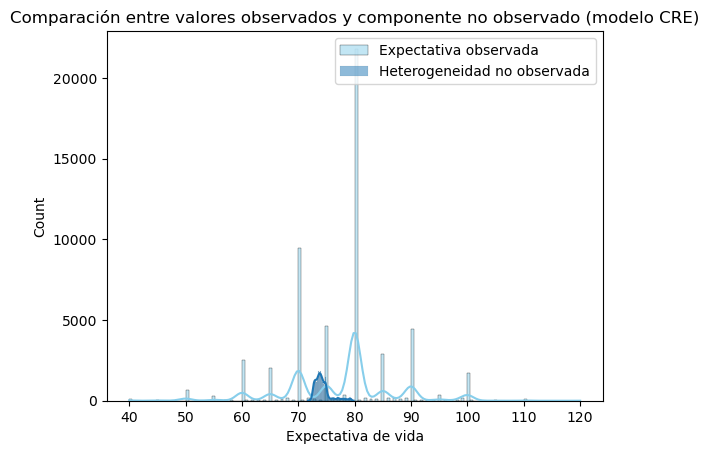

In [584]:
# Crear copia de X_cre con las mismas columnas que usaste en el modelo
Xpred = X_cre.copy()

# Poner en cero solo las variables observables (mantén los promedios como están)
variables_a_cero = [
    "wage", "edu", "exp", "sistema", "informal",
    "cronica", "missing_assets", "status_4.0", "region_3.0", "region_8.0",
    "region_4.0", "region_5.0", "region_6.0", "region_9.0",
    "region_11.0", "region_13.0", "year", "situation_4",
    'occupation_3.0', 'occupation_4.0', 'occupation_5.0',
    'occupation_6.0', 'occupation_7.0', 'occupation_8.0',
    'occupation_9.0', 'occupation_10.0'
]

for var in variables_a_cero:
    if var in Xpred.columns:
        Xpred[var] = 0

# Predecir la parte no observada
yhat = cre.predict(Xpred)

# Graficar distribución observada vs heterogeneidad no observada
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(data=y, color="skyblue", label="Expectativa observada", kde=True)
sns.histplot(data=yhat, color="red", label="Heterogeneidad no observada", kde=True)

plt.legend()
plt.xlabel("Expectativa de vida")
plt.title("Comparación entre valores observados y componente no observado (modelo CRE)")
plt.show()


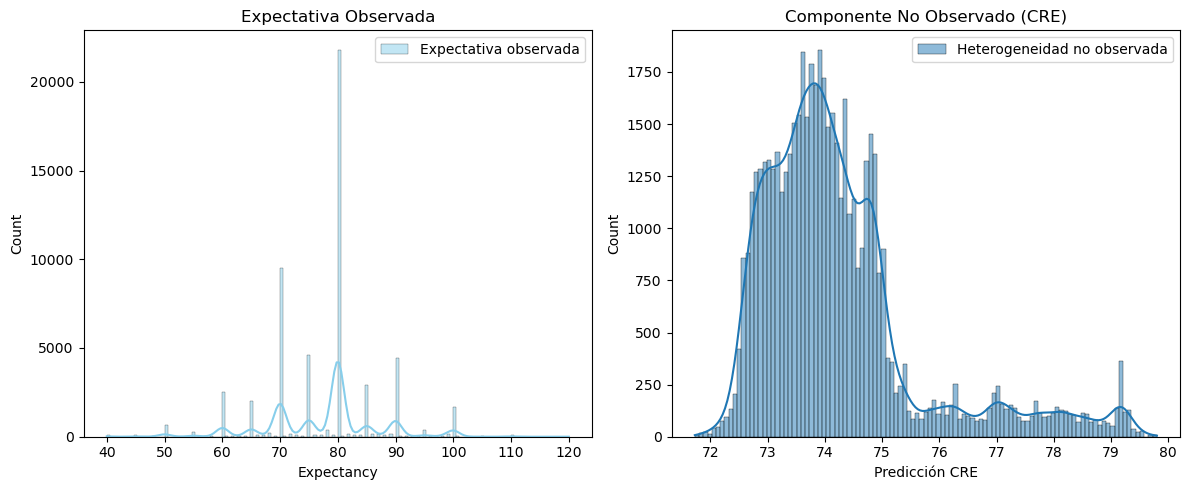

In [585]:
# Crear copia de X_cre con las mismas columnas que usaste en el modelo
Xpred = X_cre.copy()

# Poner en cero las variables observables (manteniendo los promedios)
variables_a_cero = [
    "wage", "edu", "exp", "sistema", "informal",
    "cronica", "missing_assets", "status_4.0", "region_3.0", "region_4.0", "region_5.0",
    "region_6.0", "region_8.0", "region_9.0", "region_11.0", "region_13.0",
    "year", "situation_4",
    'occupation_3.0', 'occupation_4.0', 'occupation_5.0',
    'occupation_6.0', 'occupation_7.0', 'occupation_8.0',
    'occupation_9.0', 'occupation_10.0'
]

for var in variables_a_cero:
    if var in Xpred.columns:
        Xpred[var] = 0

# Predecir con CRE (componente no observado)
yhat = cre.predict(Xpred)

# Graficar en dos paneles separados
import seaborn as sns
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(data=y, color="skyblue", label="Expectativa observada", kde=True, ax=ax1)
ax1.set_title('Expectativa Observada')
ax1.set_xlabel("Expectancy")
ax1.legend()

sns.histplot(data=yhat, color="red", label="Heterogeneidad no observada", kde=True, ax=ax2)
ax2.set_title('Componente No Observado (CRE)')
ax2.set_xlabel("Predicción CRE")
ax2.legend()

plt.tight_layout()
plt.show()


R: Notar que para modelo CRE se incorporaron promedios por individuo de las variables para capturar efectos no observados.

El modelo estimó un R cuadrado de 0,3565 y un R cuadrado overall de 0.0359 con múltiples variables significativas. Por ejemplo, exp y wage son positivos y significativos, mientras que cronica tiene es negativo, lo cual es esperable. Además, los promedios como wage_mean, informal_mean y sistema_mean son significativos, lo que nos valida el uso del modelo de efectos aleatorios.

Los gráficos comparan la distribución observada de la expectativa con la heterogeneidad no observada estimada. En ellos vemos que, al apagar variables observables, el modelo predice, en un rango mas acotado, una distribución más concentrada, lo que representa el componente no explicado por las variables utilizadas.

Finalmente podemos decir que el modelo CRE es adecuado para este estudio, ya que permite modelar de forma más flexible la heterogeneidad no observada. Además, confirma la robustez de varias variables muy relevantes y es superior al modelo RE.

# Distribucion del componente no observado
7. Usando el modelo CRE, prediga la distribucion del componente no observado. Que puede inferir respecto de la heterogeneidad fija en el tiempo y su impacto en la expectativa de vida?

R: Con el modelo CRE, pudimos predecir la distribución del componente no observado apagando las variables individuales observables y manteniendo los promedios por individuo. 

 Este enfoque nos permitió aislar la parte de la variación en la expectativa de vida relacionada a la heterogeneidad que es fija a lo largo del timepo. La distribución que obtuvimos es más concentrada y simetrica que la que pudimos observar en los datos reales, es decir, existe un componente individial importante fijo que explica gran parte de los cambios en la expectativa de vida. En conclusión, los factores personales que se mantienen en el tiempo, como genetica, lugar de origen, entre otros, influyen significativamente sobre la expectativa de vida a lo largo del tiempo, lo cual muestra la importancia de modelar correctamente la heterogeneidad no observada.
 

# Mejor Modelo
8. Usando sus respuestas anteriores, que modelo prefiere? que se puede inferir en general respecto del efecto de las variables explicativas sobre la expectativa de vida?


In [586]:
print(lmp.compare({"Pooled": results,"FE": fe_results, "RE": re_results,  "CRE": cre}))

                                     Model Comparison                                    
                                Pooled             FE                RE               CRE
-----------------------------------------------------------------------------------------
Dep. Variable               expectancy     expectancy        expectancy        expectancy
Estimator                     PanelOLS       PanelOLS     RandomEffects     RandomEffects
No. Observations                 54125          54125             54125             54125
Cov. Est.                   Unadjusted         Robust            Robust            Robust
R-squared                       0.0601         0.0137            0.3537            0.3565
R-Squared (Within)              0.0103         0.0137            0.0045            0.0094
R-Squared (Between)             0.0783        -0.0288            0.0533            0.0473
R-Squared (Overall)             0.0601        -0.0123            0.0381            0.0359
F-statisti

R: Considerando los resultados de los cuatro modelos, el modelo de efectos aleatorios correlacionados es el preferido. Aunque su R cuadrado overall  es similar al modelo de efectos aleatorios, el CRE permite modelar la heterogeneidad no observada incluyendo los promedios individuales, lo que es muy relevante y sugerido por el test de Hausman, que rechaza la validez del modelo RE a pesar de su R cuadrado mayor.

Además, el CRE logra estimaciones que son consistentes y significativas para variables relevantes como exp, wage o cronica, mientras que otras variables como sistema_mean e informal_mean son relevantes por su capcacidad de capturar efectos personales o estructurales fijos. 

En conslusión, se puede inferir que la expectativa de vida está influida tanto por condiciones actuales (educación, ingresos, salud) como por características individuales que se mantienen fijas en el tiempo, lo que nos dice que la mejor opción para este analisis es el modelo de efectos aleatorios correlacionados.